## Tarea 6: CNN — Soluciones (parte práctica)

Soluciones de los ejercicios de Python de la tarea de práctica. La numeración corresponde a la versión actual de `tareas/Tarea6.ipynb`. Úsalas para verificar tu trabajo (o el de tu agente) **después** de intentarlo.

Se mantiene el protocolo experimental del curso: semilla fija (`SEED = 1234`), el mismo split 90/10, **un solo factor variado a la vez**, y para cada experimento curvas + tabla resumen + interpretación con números reales.

### 0. Andamiaje reutilizado del notebook de clase

Todo lo que sigue viene de `notebooks/NotebookCNN.ipynb`: `set_seed`, `find_device`, `get_data_dir`, `count_params`, `SimpleCNN`, `train_one_epoch`, `evaluate` y `run_experiment`. Hicimos **tres adaptaciones**, todas de infraestructura (la arquitectura no cambia):

1. **`SimpleCNN(dropout_p=...)`**: la red de clase ya expone `dropout_p`, que controla el `nn.Dropout` de la cabeza densa (entre la capa de 128 unidades y la salida de 10). La reproducimos tal cual y ese es exactamente el parámetro que barremos en el ejercicio 2; no añadimos dropout en los bloques convolucionales para no mezclar dos factores.
2. **`run_experiment(..., train_loader, val_loader, ...)`**: la versión de clase usaba los `DataLoader` globales. Aquí se pasan como argumentos, porque necesitamos alternar entre el dataset completo (ejercicio 1) y `small_data` con y sin augmentación (ejercicios 2 y 3).
3. **Cronometraje**: `run_experiment` registra el tiempo de cada época con `time.perf_counter()` y sincroniza el dispositivo (`torch.mps.synchronize()` / `torch.cuda.synchronize()`) antes de leer el reloj, porque las operaciones en GPU son asíncronas y sin sincronizar se mediría solo el tiempo de *encolar* el trabajo.

Detalles del entorno: `DEVICE = find_device()` (MPS en este Mac), `num_workers=0` en los `DataLoader` (evita que el arranque de procesos hijo contamine las mediciones de tiempo) y `KMP_DUPLICATE_LIB_OK=TRUE` para el conflicto conocido de `libomp` en macOS.

In [1]:
# ---------------------------
# Imports & utilidades básicas (adaptado de notebooks/NotebookCNN.ipynb)
# ---------------------------
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # choque de libomp en macOS

import time
import random
import tempfile

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns


# ---------------------------
# Reproducibilidad y dispositivo
# ---------------------------
def set_seed(seed=1234):
    """Fija semillas para reproducibilidad (random, numpy, torch)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def find_device():
    """Detecta el mejor device disponible: CUDA > MPS (Apple) > CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def get_data_dir(preferred="../notebooks/data"):
    """Usa 'preferred' si se puede escribir; si no, cae a un temporal."""
    try:
        os.makedirs(preferred, exist_ok=True)
        return os.path.abspath(preferred)
    except Exception:
        tmp = tempfile.mkdtemp(prefix="mnist_data_")
        print(f"[warning] no se pudo usar '{preferred}', usando temporal: {tmp}")
        return tmp


def sync(device):
    """Sincroniza el dispositivo antes de leer el reloj (GPU = ejecucion asincrona)."""
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps" and hasattr(torch, "mps"):
        torch.mps.synchronize()


SEED = 1234
DEVICE = find_device()
set_seed(SEED)
DATA_ROOT = get_data_dir("../notebooks/data")

print("DEVICE   :", DEVICE)
print("DATA_ROOT:", DATA_ROOT)
print("torch    :", torch.__version__)

DEVICE   : mps
DATA_ROOT: /Users/fernandasobrino/Documents/ClasesTEC/aprendizaje-profundo-y-sus-usos-en-las-politicas-publicas/Notebooks/data
torch    : 2.11.0


In [2]:
# ---------------------------
# Modelo: SimpleCNN del notebook de clase (dropout_p en la cabeza densa)
# ---------------------------
def count_params(model):
    """Cuenta parámetros entrenables."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class SimpleCNN(nn.Module):
    """CNN pequeña para MNIST: 2 bloques conv + cabeza densa.

    dropout_p controla el nn.Dropout entre la capa densa de 128 y la salida.
    Es el único hiperparámetro de arquitectura que variamos (ejercicio 2).
    """
    def __init__(self, num_classes=10, dropout_p=0.0):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # -> 32x28x28
            nn.ReLU(),
            nn.MaxPool2d(2),                              # -> 32x14x14
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # -> 64x14x14
            nn.ReLU(),
            nn.MaxPool2d(2),                              # -> 64x7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                                 # -> 3136
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.conv_layers(x))


print("Parámetros SimpleCNN:", count_params(SimpleCNN(dropout_p=0.0)))

Parámetros SimpleCNN: 421642


In [3]:
# ---------------------------
# Entrenamiento / evaluación / experimento (adaptado del notebook de clase)
# ---------------------------
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    """Una pasada completa por el conjunto de entrenamiento."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = loss_fn(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(dim=1) == yb).sum().item()
        total += xb.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, loss_fn, device):
    """Pérdida media y accuracy sobre un loader, sin gradientes."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            running_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += xb.size(0)
    return running_loss / total, correct / total


def run_experiment(model_class,
                   model_kwargs,
                   train_loader,
                   val_loader,
                   optimizer_name="SGD_mom",
                   lr=1e-2,
                   weight_decay=0.0,
                   momentum=0.9,
                   epochs=30,
                   device=DEVICE,
                   seed=SEED,
                   label="",
                   log_every=10):
    """Entrena un modelo y devuelve (modelo, history).

    history incluye train/val loss y accuracy por época y 'epoch_time'
    (segundos por época: entrenamiento + evaluación, con el device sincronizado).
    set_seed(seed) antes de instanciar garantiza la MISMA inicialización y el
    MISMO orden de shuffling en todas las configuraciones comparadas.
    """
    set_seed(seed)
    model = model_class(**model_kwargs).to(device)
    loss_fn = nn.CrossEntropyLoss()

    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.0, weight_decay=weight_decay)
    elif optimizer_name == "SGD_mom":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError("optimizer_name desconocido")

    print(f"[{label}] {model.__class__.__name__} params={count_params(model)} "
          f"opt={optimizer_name} lr={lr} wd={weight_decay} epochs={epochs}")

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "epoch_time": []}
    for ep in range(1, epochs + 1):
        sync(device)
        t0 = time.perf_counter()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        va_loss, va_acc = evaluate(model, val_loader, loss_fn, device)
        sync(device)
        dt = time.perf_counter() - t0

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["epoch_time"].append(dt)

        if ep == 1 or ep % log_every == 0 or ep == epochs:
            print(f"  ep {ep:>3}/{epochs}  tr_loss={tr_loss:.4f} tr_acc={100*tr_acc:5.2f}%  "
                  f"val_loss={va_loss:.4f} val_acc={100*va_acc:5.2f}%  ({dt:.2f}s)")

    history["mean_epoch_time"] = float(np.mean(history["epoch_time"]))
    history["total_time"] = float(np.sum(history["epoch_time"]))
    print(f"[{label}] tiempo medio/época = {history['mean_epoch_time']:.2f}s  "
          f"total = {history['total_time']:.1f}s  val_acc final = {100*history['val_acc'][-1]:.2f}%")
    return model, history


def plot_curves(histories, title=None, figsize=(12, 4.5), show_train=True):
    """Panel izquierdo: loss. Panel derecho: accuracy. Un color por configuración,
    línea discontinua = train, línea continua = validación."""
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    colors = plt.cm.tab10.colors
    for i, (label, h) in enumerate(histories.items()):
        c = colors[i % 10]
        ep = range(1, len(h["train_loss"]) + 1)
        if show_train:
            axes[0].plot(ep, h["train_loss"], "--", color=c, alpha=0.65, label=f"{label} train")
            axes[1].plot(ep, [100 * x for x in h["train_acc"]], "--", color=c, alpha=0.65, label=f"{label} train")
        axes[0].plot(ep, h["val_loss"], "-", color=c, label=f"{label} val")
        axes[1].plot(ep, [100 * x for x in h["val_acc"]], "-", color=c, label=f"{label} val")
    axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss (cross-entropy)"); axes[0].set_title("Pérdida")
    axes[1].set_xlabel("Época"); axes[1].set_ylabel("Accuracy (%)"); axes[1].set_title("Exactitud")
    for ax in axes:
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    plt.show()

### 0.1 Datos: MNIST, normalización y splits

Un solo par de splits para todos los ejercicios:

- Normalización estándar de MNIST: media `0.1307`, desviación `0.3081`.
- Split 90/10 sobre las 60 000 imágenes de entrenamiento con `torch.Generator().manual_seed(1234)`: **54 000 train / 6 000 val**.
- `small_data` = los **primeros 2 000 índices** del split de entrenamiento (ya barajado por `random_split`, así que es una muestra aleatoria reproducible).
- El conjunto de validación es siempre el mismo (6 000 imágenes), también en los experimentos de `small_data`. Reducir la validación aumentaría la varianza de `val_acc` sin ningún beneficio: lo que el ejercicio quiere restringir es la señal de *entrenamiento*.

Hiperparámetros globales, según el enunciado: dataset completo `epochs=30, batch_size=128`; `small_data` `epochs=40, batch_size=64`.

In [4]:
# ---------------------------
# Datasets, splits y loaders
# ---------------------------
MEAN, STD = 0.1307, 0.3081
tfms_plain = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,)),
])

train_full = datasets.MNIST(root=DATA_ROOT, train=True, download=True, transform=tfms_plain)
test_ds = datasets.MNIST(root=DATA_ROOT, train=False, download=True, transform=tfms_plain)

n_total = len(train_full)
n_val = int(0.1 * n_total)
n_tr = n_total - n_val
train_split, val_split = torch.utils.data.random_split(
    train_full, [n_tr, n_val], generator=torch.Generator().manual_seed(SEED)
)

# Hiperparámetros globales del enunciado
BATCH_FULL, EPOCHS_FULL = 128, 30
BATCH_SMALL, EPOCHS_SMALL = 64, 40
N_SMALL = 2000

# num_workers=0: evita que el arranque de procesos hijo distorsione los tiempos por época
train_loader = DataLoader(train_split, batch_size=BATCH_FULL, shuffle=True, num_workers=0)
val_loader = DataLoader(val_split, batch_size=256, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0)

# small_data: los primeros N_SMALL índices del split de train (ya barajados)
small_idx = list(train_split.indices[:N_SMALL])
small_ds = Subset(train_full, small_idx)
small_loader = DataLoader(small_ds, batch_size=BATCH_SMALL, shuffle=True, num_workers=0)

print(f"train/val/test : {len(train_split)}/{len(val_split)}/{len(test_ds)}")
print(f"small_data     : {len(small_ds)} imágenes (batch={BATCH_SMALL}, epochs={EPOCHS_SMALL})")
print(f"clases en small_data: {np.bincount([train_full.targets[i].item() for i in small_idx])}")

train/val/test : 54000/6000/10000
small_data     : 2000 imágenes (batch=64, epochs=40)
clases en small_data: [205 222 214 195 201 179 206 191 187 200]


---
## Ejercicio 1 — Optimizadores: SGD con momentum vs Adam

**Enunciado.** Entrenar la `SimpleCNN` sobre MNIST completo (`epochs=30`, `batch_size=128`) con:

- `SGD(momentum=0.9, lr=1e-2)`
- `Adam(lr=1e-3)`

manteniendo **todo lo demás igual**: misma semilla, misma inicialización, mismo split, mismo orden de batches, `dropout_p=0.0`, `weight_decay=0`. Entregar curvas train/val de pérdida y accuracy en la misma figura, el **tiempo medio por época** de cada uno y un comentario de 1–2 frases sobre velocidad de convergencia y estabilidad.

**Predicción antes de correr.** Adam debería bajar la pérdida más rápido en las primeras épocas: adapta el paso por parámetro con las estimaciones de primer y segundo momento, así que no depende de acertar un único `lr` global. SGD con momentum debería alcanzarlo hacia el final y quizá generalizar un poco mejor (es el patrón clásico en visión). En **tiempo por época** esperamos una diferencia pequeña: Adam mantiene dos estados extra por parámetro (`exp_avg`, `exp_avg_sq`) y hace más operaciones elementwise en el `step`, pero con ~421 k parámetros el costo dominante es el forward/backward de las convoluciones, no la actualización. También esperamos que la `val_loss` de Adam suba al final aunque la accuracy siga bien: es el síntoma típico de sobreconfianza en las predicciones erróneas.

In [5]:
# ---------------------------
# Ejercicio 1: SGD(momentum=0.9, lr=1e-2)  vs  Adam(lr=1e-3)
# Todo lo demás fijo: misma semilla -> misma init y mismo shuffling
# ---------------------------
hist_opt = {}

_, hist_opt["SGD_mom (lr=1e-2)"] = run_experiment(
    SimpleCNN, {"dropout_p": 0.0}, train_loader, val_loader,
    optimizer_name="SGD_mom", lr=1e-2, momentum=0.9, weight_decay=0.0,
    epochs=EPOCHS_FULL, seed=SEED, label="SGD_mom", log_every=5,
)

_, hist_opt["Adam (lr=1e-3)"] = run_experiment(
    SimpleCNN, {"dropout_p": 0.0}, train_loader, val_loader,
    optimizer_name="Adam", lr=1e-3, weight_decay=0.0,
    epochs=EPOCHS_FULL, seed=SEED, label="Adam", log_every=5,
)

[SGD_mom] SimpleCNN params=421642 opt=SGD_mom lr=0.01 wd=0.0 epochs=30


  ep   1/30  tr_loss=0.2884 tr_acc=91.54%  val_loss=0.0820 val_acc=97.57%  (3.90s)


  ep   5/30  tr_loss=0.0292 tr_acc=99.11%  val_loss=0.0392 val_acc=98.80%  (3.94s)


  ep  10/30  tr_loss=0.0123 tr_acc=99.62%  val_loss=0.0336 val_acc=99.08%  (3.82s)


  ep  15/30  tr_loss=0.0045 tr_acc=99.88%  val_loss=0.0355 val_acc=99.18%  (3.57s)


...

  ep  10/30  tr_loss=0.0084 tr_acc=99.70%  val_loss=0.0443 val_acc=98.95%  (3.79s)


  ep  15/30  tr_loss=0.0056 tr_acc=99.80%  val_loss=0.0402 val_acc=99.23%  (3.91s)


  ep  20/30  tr_loss=0.0048 tr_acc=99.83%  val_loss=0.0624 val_acc=98.93%  (3.71s)


  ep  25/30  tr_loss=0.0009 tr_acc=99.97%  val_loss=0.0475 val_acc=99.10%  (3.71s)


  ep  30/30  tr_loss=0.0033 tr_acc=99.89%  val_loss=0.0594 val_acc=98.98%  (3.63s)
[Adam] tiempo medio/época = 3.75s  total = 112.5s  val_acc final = 98.98%


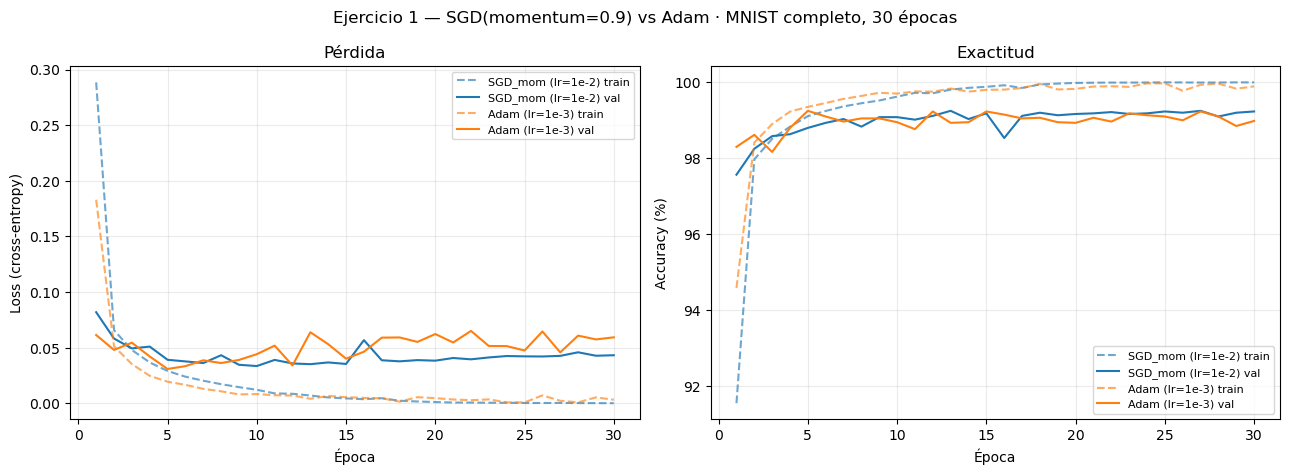

In [6]:
# Curvas pareadas (misma figura): discontinua = train, continua = validación
plot_curves(hist_opt, title="Ejercicio 1 — SGD(momentum=0.9) vs Adam · MNIST completo, 30 épocas",
            figsize=(13, 4.8))

In [7]:
# ---------------------------
# Tabla resumen del ejercicio 1
# ---------------------------
def epochs_to_reach(h, target=0.98):
    """Primera época en que val_acc alcanza 'target' (None si nunca)."""
    for i, a in enumerate(h["val_acc"], start=1):
        if a >= target:
            return i
    return None

rows = []
for label, h in hist_opt.items():
    rows.append({
        "optimizador": label,
        "t/época (s)": round(h["mean_epoch_time"], 2),
        "sd t/época": round(float(np.std(h["epoch_time"])), 2),
        "tiempo total (s)": round(h["total_time"], 1),
        "val_acc ép.1 (%)": round(100 * h["val_acc"][0], 2),
        "val_acc ép.5 (%)": round(100 * h["val_acc"][min(4, len(h["val_acc"]) - 1)], 2),
        "val_acc final (%)": round(100 * h["val_acc"][-1], 2),
        "val_acc máx (%)": round(100 * max(h["val_acc"]), 2),
        "épocas → 98% val": epochs_to_reach(h, 0.98),
        "val_loss mín": round(min(h["val_loss"]), 4),
        "val_loss final": round(h["val_loss"][-1], 4),
        "gap final (tr-val acc, pp)": round(100 * (h["train_acc"][-1] - h["val_acc"][-1]), 2),
    })

tabla_opt = pd.DataFrame(rows).set_index("optimizador")
display(tabla_opt.T)

for label, h in hist_opt.items():
    print(f"{label}: tiempo medio por época = {h['mean_epoch_time']:.2f} s "
          f"(± {np.std(h['epoch_time']):.2f} s), 30 épocas en {h['total_time']:.1f} s")

optimizador,SGD_mom (lr=1e-2),Adam (lr=1e-3)
t/época (s),3.5100,3.7500
sd t/época,0.1500,0.0900
tiempo total (s),105.2000,112.5000
val_acc ép.1 (%),97.5700,98.3000
val_acc ép.5 (%),98.8000,99.2500
val_acc final (%),99.2300,98.9800
val_acc máx (%),99.2500,99.2500
épocas → 98% val,2.0000,1.0000
val_loss mín,0.0336,0.0310
val_loss final,0.0433,0.0594


SGD_mom (lr=1e-2): tiempo medio por época = 3.51 s (± 0.15 s), 30 épocas en 105.2 s
Adam (lr=1e-3): tiempo medio por época = 3.75 s (± 0.09 s), 30 épocas en 112.5 s


**Interpretación:**

**Tiempo por época.** SGD con momentum: **3.51 s/época** (± 0.15 s), 105.2 s las 30 épocas. Adam: **3.75 s/época** (± 0.09 s), 112.5 s en total. Adam es **~7 % más lento por época** (+0.24 s), y la diferencia es real: es más de una desviación estándar de las mediciones. La explicación es el costo del `step`: Adam mantiene dos buffers de estado por parámetro (`exp_avg` y `exp_avg_sq`) y hace varias operaciones elementwise extra sobre los 421 642 parámetros, mientras que SGD con momentum mantiene uno solo. Aun así la diferencia es pequeña en términos relativos, porque en una CNN el grueso del tiempo se va en el forward/backward de las convoluciones, no en la actualización de los pesos.

**Velocidad de convergencia.** Adam va por delante desde el principio: alcanza 98 % de `val_acc` en **1 época** (SGD necesita 2), y en la época 1 ya va 97.57 % → 98.30 % a favor de Adam; en la época 5 la ventaja sigue (98.80 % vs 99.25 %). También llega antes al mínimo de `val_loss` (0.0310 en la época 5 frente a 0.0336 de SGD). Esto es lo esperado: el paso adaptativo por parámetro de Adam evita tener que acertar un único `lr` global.

**Estabilidad y resultado final.** El orden se invierte al final: SGD termina en **99.23 %** de `val_acc` y Adam en **98.98 %**; el máximo es idéntico (99.25 % ambos), pero SGD lo sostiene y Adam oscila (98.95 %, 99.23 %, 98.93 %, 99.10 %, 98.98 % en las épocas 10–30). La `val_loss` final lo dice más claro: **0.0433 (SGD) vs 0.0594 (Adam)**, ambas por encima de su mínimo. Es decir: los dos sobreajustan (`train_acc` = 100 % con `train_loss` ~2e-4), pero Adam se vuelve más *sobreconfiado* en los ejemplos que falla, y por eso su pérdida de validación crece más aunque la accuracy apenas cambie.

**Veredicto (1–2 frases).** Adam converge más rápido —98 % de validación en la primera época frente a dos de SGD— a un costo del 7 % más de tiempo por época; pero SGD con momentum termina mejor y más estable (99.23 % vs 98.98 % de `val_acc`, `val_loss` 0.0433 vs 0.0594). Con presupuesto corto de épocas conviene Adam; con 30 épocas completas, SGD+momentum. Esto confirma la predicción, incluida la subida de `val_loss` de Adam al final.

---
## Ejercicio 2 — Regularización: grid 3×3 de `dropout_p` × `weight_decay`

**Enunciado.** Con `small_data` (`train_size=2000`, `epochs=40`, `batch_size=64`) y `SGD(momentum=0.9, lr=1e-2)`, entrenar las 9 combinaciones de `dropout_p ∈ {0.0, 0.2, 0.5}` × `weight_decay ∈ {0, 1e-4, 1e-3}`. Entregar heatmap/tabla de `val_acc` final, curvas train/val loss de las 3 mejores y la mejor combinación justificada.

**Predicción antes de correr.** Con solo 2 000 ejemplos y 421 k parámetros el modelo está enormemente sobreparametrizado, así que esperamos sobreajuste claro (train_acc → 100 %, val_loss subiendo tras un mínimo temprano) y por tanto margen para que la regularización ayude.

- **Dropout**: `0.2` debería ayudar algo; `0.5` en una capa de 128 unidades puede ser demasiado agresivo y frenar el ajuste, sobre todo con solo 40 épocas y `lr` moderado.
- **Weight decay**: `1e-4` es prácticamente inocuo a esta escala de `lr`; `1e-3` sí debería notarse un poco. En SGD el `weight_decay` de PyTorch es L2 añadido al gradiente, con efecto proporcional a `lr·wd` — con `lr=1e-2` eso es un encogimiento de 1e-5 por paso, muy suave.
- Esperamos que el efecto del **dropout domine** sobre el del weight decay, y que las diferencias entre celdas sean del orden de décimas de punto porcentual, o sea comparables al ruido de una sola corrida. Por eso, además de `val_acc` final reportamos la media de las últimas 5 épocas: es un estimador menos ruidoso del mismo desempeño.

In [8]:
# ---------------------------
# Ejercicio 2: grid dropout_p x weight_decay sobre small_data
# ---------------------------
DROPOUTS = [0.0, 0.2, 0.5]
WDS = [0.0, 1e-4, 1e-3]

hist_grid = {}
grid_rows = []

t_grid0 = time.perf_counter()
for p in DROPOUTS:
    for wd in WDS:
        key = f"p={p}, wd={wd:g}"
        _, h = run_experiment(
            SimpleCNN, {"dropout_p": p}, small_loader, val_loader,
            optimizer_name="SGD_mom", lr=1e-2, momentum=0.9, weight_decay=wd,
            epochs=EPOCHS_SMALL, seed=SEED, label=key, log_every=20,
        )
        hist_grid[key] = h
        grid_rows.append({
            "dropout_p": p,
            "weight_decay": wd,
            "val_acc_final": 100 * h["val_acc"][-1],
            "val_acc_ult5": 100 * float(np.mean(h["val_acc"][-5:])),
            "val_acc_max": 100 * max(h["val_acc"]),
            "val_loss_final": h["val_loss"][-1],
            "val_loss_min": min(h["val_loss"]),
            "ep_val_loss_min": int(np.argmin(h["val_loss"])) + 1,
            "train_acc_final": 100 * h["train_acc"][-1],
            "gap_pp": 100 * (h["train_acc"][-1] - h["val_acc"][-1]),
        })
print(f"\nGrid completo en {(time.perf_counter()-t_grid0)/60:.1f} min")

grid_df = pd.DataFrame(grid_rows)
grid_df.round(3)

[p=0.0, wd=0] SimpleCNN params=421642 opt=SGD_mom lr=0.01 wd=0.0 epochs=40


  ep   1/40  tr_loss=1.6919 tr_acc=51.80%  val_loss=1.3273 val_acc=60.17%  (0.50s)


  ep  20/40  tr_loss=0.0026 tr_acc=100.00%  val_loss=0.1765 val_acc=95.85%  (0.41s)


  ep  40/40  tr_loss=0.0005 tr_acc=100.00%  val_loss=0.2039 val_acc=95.78%  (0.41s)
[p=0.0, wd=0] tiempo medio/época = 0.40s  total = 16.2s  val_acc final = 95.78%
[p=0.0, wd=0.0001] SimpleCNN params=421642 opt=SGD_mom lr=0.01 wd=0.0001 epochs=40


  ep   1/40  tr_loss=1.6923 tr_acc=51.65%  val_loss=1.3344 val_acc=60.18%  (0.39s)


...

  ep  40/40  tr_loss=0.0223 tr_acc=99.30%  val_loss=0.1446 val_acc=96.73%  (0.45s)
[p=0.5, wd=0.0001] tiempo medio/época = 0.41s  total = 16.4s  val_acc final = 96.73%
[p=0.5, wd=0.001] SimpleCNN params=421642 opt=SGD_mom lr=0.01 wd=0.001 epochs=40


  ep   1/40  tr_loss=1.8432 tr_acc=38.70%  val_loss=0.8605 val_acc=69.90%  (0.39s)


  ep  20/40  tr_loss=0.0486 tr_acc=98.60%  val_loss=0.1358 val_acc=96.18%  (0.39s)


  ep  40/40  tr_loss=0.0225 tr_acc=99.30%  val_loss=0.1247 val_acc=96.95%  (0.40s)
[p=0.5, wd=0.001] tiempo medio/época = 0.42s  total = 16.6s  val_acc final = 96.95%

Grid completo en 2.4 min


,dropout_p,weight_decay,val_acc_final,val_acc_ult5,val_acc_max,val_loss_final,val_loss_min,ep_val_loss_min,train_acc_final,gap_pp
0,0.0,0.000,95.783,95.857,95.900,0.204,0.154,13,100.00,4.217
1,0.0,0.000,95.817,95.847,95.950,0.195,0.151,13,100.00,4.183
2,0.0,0.001,95.800,95.867,95.983,0.170,0.151,13,100.00,4.200
3,0.2,0.000,96.317,96.220,96.567,0.161,0.148,17,99.85,3.533
4,0.2,0.000,96.367,96.350,96.433,0.154,0.145,27,99.90,3.533
5,0.2,0.001,96.217,96.240,96.367,0.144,0.142,33,99.80,3.583
6,0.5,0.000,96.783,96.647,96.900,0.132,0.123,24,99.25,2.467
7,0.5,0.000,96.733,96.723,96.850,0.145,0.124,33,99.30,2.567
8,0.5,0.001,96.950,96.670,96.950,0.125,0.124,39,99.30,2.350


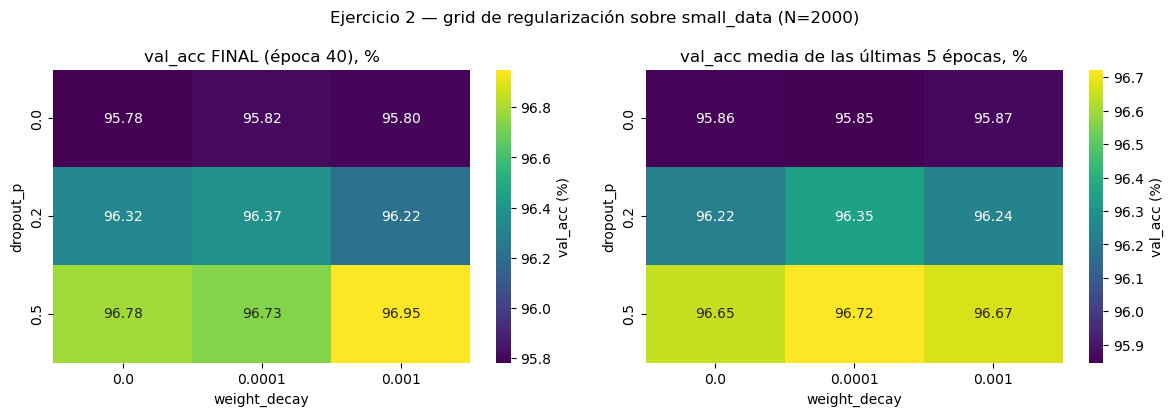

,dropout_p,weight_decay,val_acc_final,val_acc_ult5,val_acc_max,val_loss_final,val_loss_min,ep_val_loss_min,train_acc_final,gap_pp
0,0.5,0.001,96.950,96.670,96.950,0.125,0.124,39,99.30,2.350
1,0.5,0.000,96.783,96.647,96.900,0.132,0.123,24,99.25,2.467
2,0.5,0.000,96.733,96.723,96.850,0.145,0.124,33,99.30,2.567
3,0.2,0.000,96.367,96.350,96.433,0.154,0.145,27,99.90,3.533
4,0.2,0.000,96.317,96.220,96.567,0.161,0.148,17,99.85,3.533
5,0.2,0.001,96.217,96.240,96.367,0.144,0.142,33,99.80,3.583
6,0.0,0.000,95.817,95.847,95.950,0.195,0.151,13,100.00,4.183
7,0.0,0.001,95.800,95.867,95.983,0.170,0.151,13,100.00,4.200
8,0.0,0.000,95.783,95.857,95.900,0.204,0.154,13,100.00,4.217



Mejor por val_acc final: dropout_p=0.5, weight_decay=0.001 -> 96.95% (últimas 5 épocas: 96.67%)
Mejor por media de últimas 5 épocas: dropout_p=0.5, weight_decay=0.0001 -> 96.72%
Rango del grid (val_acc final): 95.78% – 96.95%  (amplitud 1.17 pp)


In [9]:
# ---------------------------
# Heatmap de val_acc final (%) y tabla ordenada
# ---------------------------
pivot_final = grid_df.pivot(index="dropout_p", columns="weight_decay", values="val_acc_final")
pivot_ult5 = grid_df.pivot(index="dropout_p", columns="weight_decay", values="val_acc_ult5")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.heatmap(pivot_final, annot=True, fmt=".2f", cmap="viridis", cbar_kws={"label": "val_acc (%)"}, ax=axes[0])
axes[0].set_title("val_acc FINAL (época 40), %")
sns.heatmap(pivot_ult5, annot=True, fmt=".2f", cmap="viridis", cbar_kws={"label": "val_acc (%)"}, ax=axes[1])
axes[1].set_title("val_acc media de las últimas 5 épocas, %")
for ax in axes:
    ax.set_xlabel("weight_decay")
    ax.set_ylabel("dropout_p")
fig.suptitle("Ejercicio 2 — grid de regularización sobre small_data (N=2000)")
fig.tight_layout()
plt.show()

ranking = grid_df.sort_values("val_acc_final", ascending=False).reset_index(drop=True)
display(ranking.round(3))

best = ranking.iloc[0]
print(f"\nMejor por val_acc final: dropout_p={best.dropout_p}, weight_decay={best.weight_decay:g} "
      f"-> {best.val_acc_final:.2f}% (últimas 5 épocas: {best.val_acc_ult5:.2f}%)")
best5 = grid_df.sort_values("val_acc_ult5", ascending=False).iloc[0]
print(f"Mejor por media de últimas 5 épocas: dropout_p={best5.dropout_p}, "
      f"weight_decay={best5.weight_decay:g} -> {best5.val_acc_ult5:.2f}%")
print(f"Rango del grid (val_acc final): {grid_df.val_acc_final.min():.2f}% – "
      f"{grid_df.val_acc_final.max():.2f}%  (amplitud {grid_df.val_acc_final.max()-grid_df.val_acc_final.min():.2f} pp)")

Top-3 por val_acc final: ['p=0.5, wd=0.001', 'p=0.5, wd=0', 'p=0.5, wd=0.0001']


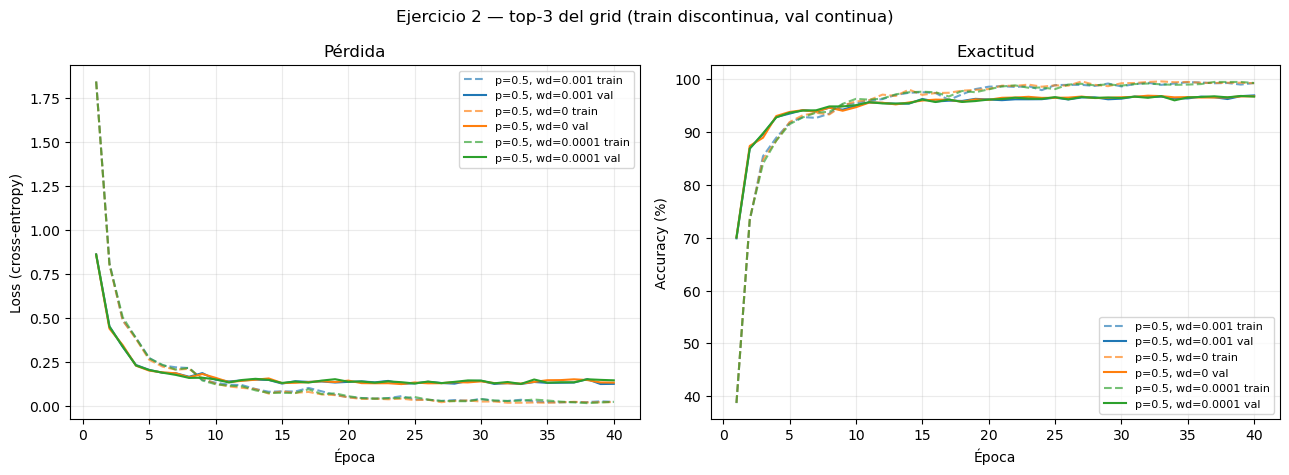


val_acc final promedio por dropout_p:
dropout_p
0.0    95.800
0.2    96.300
0.5    96.822

val_acc final promedio por weight_decay:
weight_decay
0.0000    96.294
0.0001    96.306
0.0010    96.322


In [10]:
# ---------------------------
# Curvas train/val loss de las 3 mejores combinaciones
# ---------------------------
top3 = ranking.head(3)
top3_keys = [f"p={r.dropout_p}, wd={r.weight_decay:g}" for r in top3.itertuples()]
print("Top-3 por val_acc final:", top3_keys)

plot_curves({k: hist_grid[k] for k in top3_keys},
            title="Ejercicio 2 — top-3 del grid (train discontinua, val continua)",
            figsize=(13, 4.8))

# Efecto marginal de cada factor (promediando sobre el otro)
print("\nval_acc final promedio por dropout_p:")
print(grid_df.groupby("dropout_p").val_acc_final.mean().round(3).to_string())
print("\nval_acc final promedio por weight_decay:")
print(grid_df.groupby("weight_decay").val_acc_final.mean().round(3).to_string())

**Interpretación:**

**Efecto dominante: dropout.** Promediando sobre `weight_decay`, la `val_acc` final sube monótonamente con el dropout: **95.80 % (p=0.0) → 96.30 % (p=0.2) → 96.82 % (p=0.5)**, es decir **+1.02 pp** de p=0 a p=0.5. El grid completo va de 95.78 % a 96.95 % (amplitud 1.17 pp), así que prácticamente toda la variación del experimento la explica el dropout. Contra lo que predijimos, `p=0.5` **no** resultó demasiado agresivo: las tres celdas con p=0.5 son las tres mejores del grid.

**Efecto del weight decay: indistinguible del ruido.** Promediando sobre el dropout: **96.294 % (wd=0) → 96.306 % (wd=1e-4) → 96.322 % (wd=1e-3)**. Son **0.03 pp** de diferencia total, o sea unas 2 imágenes de las 6 000 de validación: no es una señal, es ruido. Esto era lo predicho y tiene una razón concreta: en SGD el `weight_decay` de PyTorch se suma al gradiente, con un encogimiento efectivo de `lr·wd` por paso; con `lr=1e-2` y `wd=1e-3` eso es 1e-5 por paso, demasiado suave para competir con dropout en 40 épocas.

**El diagnóstico de sobreajuste confirma el mecanismo.** Sin dropout, la `val_loss` toca su mínimo en la **época 13** y luego sube durante 27 épocas mientras `train_acc` se queda clavada en 100.00 % — sobreajuste de manual, con un gap train−val de **4.20 pp**. Con p=0.5 el mínimo de `val_loss` se corre a las épocas **24–39** (o sea, todavía está mejorando cuando el entrenamiento termina), `train_acc` se queda en 99.25–99.30 % y el gap baja a **2.35–2.57 pp**. El dropout no solo mejora el número final: retrasa el punto en que el modelo empieza a memorizar.

**Mejor combinación y justificación.** Por `val_acc` final gana **`dropout_p=0.5, weight_decay=1e-3` con 96.95 %** (+1.17 pp sobre la peor celda). Por media de las últimas 5 épocas —estimador menos ruidoso— gana `dropout_p=0.5, weight_decay=1e-4` con 96.72 %, y las tres celdas de p=0.5 quedan entre 96.65 % y 96.72 %: **empatadas dentro del ruido**. La lectura honesta es entonces: **elegir `dropout_p=0.5` es la decisión que importa, y el `weight_decay` da igual dentro del rango probado**. Si hay que reportar una sola configuración, `dropout_p=0.5, weight_decay=1e-3`: gana en `val_acc` final (96.95 %), tiene la `val_loss` final más baja del grid (0.125) y el gap train−val más pequeño (2.35 pp), y su `val_loss` seguía bajando en la época 39 — es la única celda que aún no había empezado a sobreajustar.

**Advertencia metodológica.** Todo esto es una sola corrida por celda con semilla fija. Diferencias de ~0.1–0.2 pp entre celdas (por ejemplo, las tres de p=0.5 entre sí) no son concluyentes; para afirmarlas habría que repetir con varias semillas y reportar media ± desviación. La conclusión que sí resiste es la del factor dropout, porque es un efecto de ~1 pp monótono en los tres niveles.

---
## Ejercicio 3 — Data augmentation sobre `small_data`

**Enunciado.** Con `train_size=2000` comparar tres condiciones (todo lo demás fijo: `SGD(momentum=0.9, lr=1e-2)`, `dropout_p=0.0`, `weight_decay=0`, 40 épocas, batch 64):

1. **Baseline**: sin augmentación.
2. **Augmentación conservadora**: `RandomRotation(±10°)` + `RandomAffine(translate=±2 px, scale=(0.95, 1.05))`.
3. **Ruido de entrada**: ruido gaussiano en los píxeles durante el entrenamiento, `sigma ≈ 0.05`.

Entregar curvas train/val loss, `val_acc` final de las tres condiciones, un grid visual de 6–9 augmentaciones de la misma imagen (para mostrar que preservan la etiqueta) y una conclusión sobre si la augmentación ayuda con pocos datos.

**Nota de implementación.** El orden importa: la augmentación geométrica y el ruido se aplican **sobre los píxeles en [0, 1]**, y la normalización (`(x-0.1307)/0.3081`) va al final. `translate=(2/28, 2/28)` porque `RandomAffine` recibe la traslación como fracción del ancho de la imagen. La augmentación se aplica **solo al conjunto de entrenamiento**; validación y test siempre usan `tfms_plain`, si no las métricas no serían comparables.

**Predicción antes de correr.** Con 2 000 ejemplos el régimen es de sobreajuste, que es exactamente donde la augmentación debería pagar: esperamos que la condición geométrica suba `val_acc` respecto al baseline (las rotaciones/traslaciones pequeñas son invarianzas reales de los dígitos escritos a mano, y una CNN con solo dos `MaxPool2d` es únicamente invariante a traslaciones muy pequeñas) a costa de un `train_acc` menor y convergencia más lenta. El ruido gaussiano con `sigma=0.05` es una perturbación pequeña comparada con el contraste de MNIST (los trazos van a ~1.0 sobre fondo 0.0): esperamos un efecto casi nulo, quizá una mejora marginal.

In [11]:
# ---------------------------
# Ejercicio 3: transforms de las tres condiciones
# ---------------------------
class AddGaussianNoise:
    """Ruido gaussiano aditivo sobre los píxeles en [0,1], antes de normalizar.

    Se aplica en cada acceso al dataset, o sea que cada época ve una realización
    distinta del ruido: es augmentación estocástica, no un dataset ruidoso fijo.
    """
    def __init__(self, sigma=0.05, clamp=True):
        self.sigma = sigma
        self.clamp = clamp

    def __call__(self, x):
        out = x + torch.randn_like(x) * self.sigma
        return out.clamp(0.0, 1.0) if self.clamp else out

    def __repr__(self):
        return f"AddGaussianNoise(sigma={self.sigma})"


tfms_aug_geom = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(2 / 28, 2 / 28), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,)),
])

tfms_aug_noise = transforms.Compose([
    transforms.ToTensor(),
    AddGaussianNoise(sigma=0.05),
    transforms.Normalize((MEAN,), (STD,)),
])

# Mismos 2000 índices en las tres condiciones: solo cambia la transformación
small_geom = Subset(datasets.MNIST(root=DATA_ROOT, train=True, download=False, transform=tfms_aug_geom), small_idx)
small_noise = Subset(datasets.MNIST(root=DATA_ROOT, train=True, download=False, transform=tfms_aug_noise), small_idx)

loader_base = small_loader
loader_geom = DataLoader(small_geom, batch_size=BATCH_SMALL, shuffle=True, num_workers=0)
loader_noise = DataLoader(small_noise, batch_size=BATCH_SMALL, shuffle=True, num_workers=0)

print("baseline :", tfms_plain)
print("geom     :", tfms_aug_geom)
print("noise    :", tfms_aug_noise)

baseline : Compose(
    ToTensor()
    Normalize(mean=(0.1307,), std=(0.3081,))
)
geom     : Compose(
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.07142857142857142, 0.07142857142857142), scale=(0.95, 1.05))
    ToTensor()
    Normalize(mean=(0.1307,), std=(0.3081,))
)
noise    : Compose(
    ToTensor()
    AddGaussianNoise(sigma=0.05)
    Normalize(mean=(0.1307,), std=(0.3081,))
)


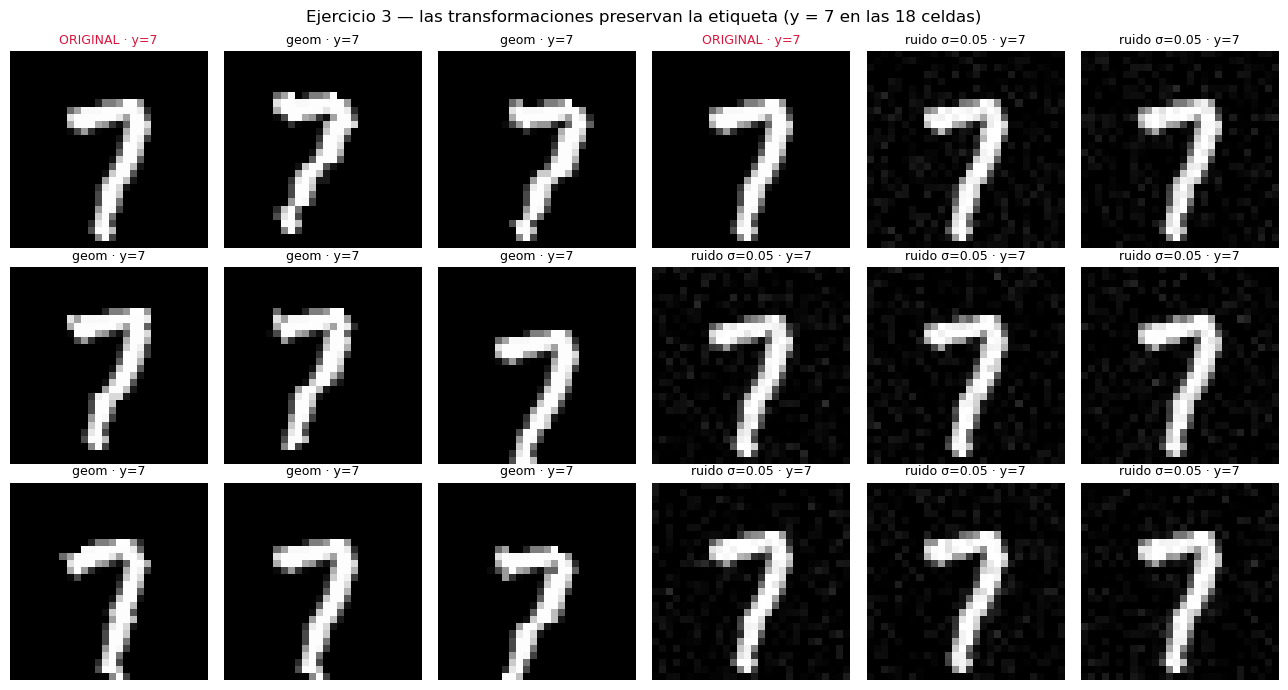

Etiqueta invariante: y = 7. Rotación ≤10°, traslación ≤2 px y escala 0.95–1.05 no convierten un 7 en otro dígito; el ruido σ=0.05 es pequeño frente al contraste trazo/fondo (~1.0).


In [12]:
# ---------------------------
# Grid visual: 9 realizaciones de la augmentación sobre la MISMA imagen
# ---------------------------
raw_ds = datasets.MNIST(root=DATA_ROOT, train=True, download=False, transform=None)
idx0 = small_idx[0]
img_pil, label0 = raw_ds[idx0]

set_seed(SEED)
fig, axes = plt.subplots(3, 6, figsize=(13, 7))

# Fila 0..2, columnas 0..2 -> augmentación geométrica; columnas 3..5 -> ruido gaussiano
for k in range(9):
    r, c = divmod(k, 3)
    x = tfms_aug_geom(img_pil) * STD + MEAN            # desnormalizar para visualizar
    axes[r][c].imshow(x.squeeze(0), cmap="gray", vmin=0, vmax=1)
    axes[r][c].set_title(f"geom · y={label0}", fontsize=9)
    axes[r][c].axis("off")

    xn = tfms_aug_noise(img_pil) * STD + MEAN
    axes[r][c + 3].imshow(xn.squeeze(0), cmap="gray", vmin=0, vmax=1)
    axes[r][c + 3].set_title(f"ruido σ=0.05 · y={label0}", fontsize=9)
    axes[r][c + 3].axis("off")

# La primera celda de cada bloque se sustituye por el original para comparar
x0 = tfms_plain(img_pil) * STD + MEAN
axes[0][0].imshow(x0.squeeze(0), cmap="gray", vmin=0, vmax=1)
axes[0][0].set_title(f"ORIGINAL · y={label0}", fontsize=9, color="crimson")
axes[0][3].imshow(x0.squeeze(0), cmap="gray", vmin=0, vmax=1)
axes[0][3].set_title(f"ORIGINAL · y={label0}", fontsize=9, color="crimson")

fig.suptitle(f"Ejercicio 3 — las transformaciones preservan la etiqueta (y = {label0} en las 18 celdas)")
fig.tight_layout()
plt.show()

print(f"Etiqueta invariante: y = {label0}. Rotación ≤10°, traslación ≤2 px y escala 0.95–1.05 "
      f"no convierten un {label0} en otro dígito; el ruido σ=0.05 es pequeño frente al contraste trazo/fondo (~1.0).")

In [13]:
# ---------------------------
# Ejercicio 3: entrenamiento de las tres condiciones
# ---------------------------
hist_aug = {}
cfgs_aug = [
    ("baseline (sin augment)", loader_base),
    ("geom (rot±10°, ±2px, scale)", loader_geom),
    ("ruido gaussiano σ=0.05", loader_noise),
]

for label, ldr in cfgs_aug:
    _, hist_aug[label] = run_experiment(
        SimpleCNN, {"dropout_p": 0.0}, ldr, val_loader,
        optimizer_name="SGD_mom", lr=1e-2, momentum=0.9, weight_decay=0.0,
        epochs=EPOCHS_SMALL, seed=SEED, label=label, log_every=20,
    )

[baseline (sin augment)] SimpleCNN params=421642 opt=SGD_mom lr=0.01 wd=0.0 epochs=40


  ep   1/40  tr_loss=1.6919 tr_acc=51.80%  val_loss=1.3273 val_acc=60.17%  (0.42s)


  ep  20/40  tr_loss=0.0026 tr_acc=100.00%  val_loss=0.1765 val_acc=95.85%  (0.39s)


  ep  40/40  tr_loss=0.0005 tr_acc=100.00%  val_loss=0.2039 val_acc=95.78%  (0.43s)
[baseline (sin augment)] tiempo medio/época = 0.42s  total = 17.0s  val_acc final = 95.78%
[geom (rot±10°, ±2px, scale)] SimpleCNN params=421642 opt=SGD_mom lr=0.01 wd=0.0 epochs=40


  ep   1/40  tr_loss=1.9185 tr_acc=39.70%  val_loss=1.2052 val_acc=52.93%  (0.48s)


  ep  20/40  tr_loss=0.0744 tr_acc=97.65%  val_loss=0.1125 val_acc=96.60%  (0.49s)


  ep  40/40  tr_loss=0.0323 tr_acc=99.30%  val_loss=0.0788 val_acc=97.88%  (0.45s)
[geom (rot±10°, ±2px, scale)] tiempo medio/época = 0.48s  total = 19.2s  val_acc final = 97.88%
[ruido gaussiano σ=0.05] SimpleCNN params=421642 opt=SGD_mom lr=0.01 wd=0.0 epochs=40


  ep   1/40  tr_loss=1.7082 tr_acc=50.80%  val_loss=1.3337 val_acc=59.65%  (0.44s)


  ep  20/40  tr_loss=0.0024 tr_acc=100.00%  val_loss=0.1989 val_acc=95.35%  (0.45s)


  ep  40/40  tr_loss=0.0006 tr_acc=100.00%  val_loss=0.2204 val_acc=95.38%  (0.47s)
[ruido gaussiano σ=0.05] tiempo medio/época = 0.44s  total = 17.6s  val_acc final = 95.38%


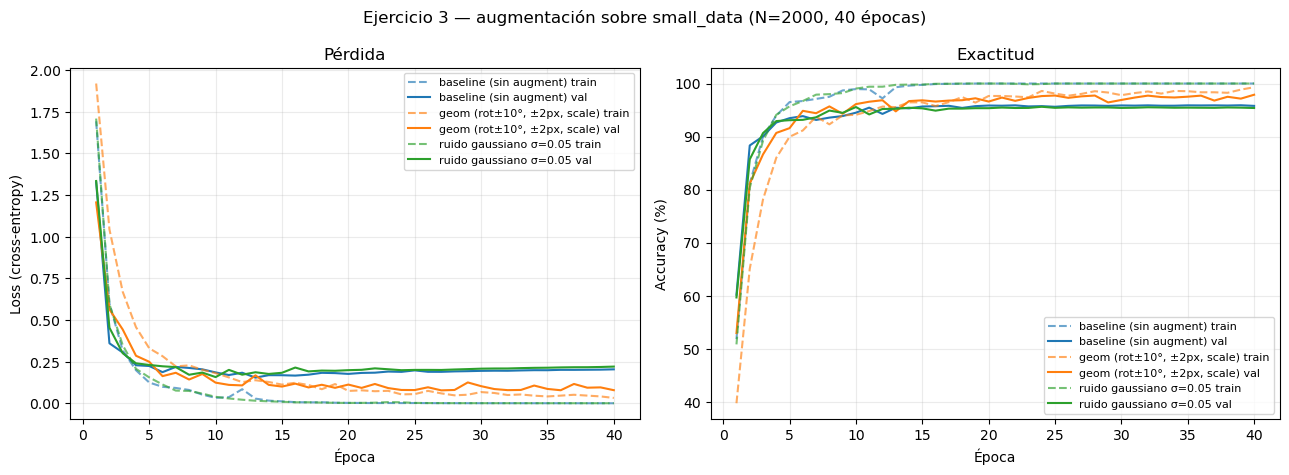

condición,baseline (sin augment),"geom (rot±10°, ±2px, scale)",ruido gaussiano σ=0.05
val_acc final (%),95.7800,97.8800,95.3800
val_acc últ.5 (%),95.8600,97.4100,95.4300
val_acc máx (%),95.9000,97.8800,95.6200
train_acc final (%),100.0000,99.3000,100.0000
gap (pp),4.2200,1.4200,4.6200
val_loss final,0.2039,0.0788,0.2204
val_loss mín,0.1542,0.0778,0.1574
época del mín,13.0000,27.0000,10.0000
t/época (s),0.4200,0.4800,0.4400


geom (rot±10°, ±2px, scale): +2.10 pp de val_acc vs baseline
ruido gaussiano σ=0.05: -0.40 pp de val_acc vs baseline


In [14]:
plot_curves(hist_aug, title="Ejercicio 3 — augmentación sobre small_data (N=2000, 40 épocas)",
            figsize=(13, 4.8))

rows = []
for label, h in hist_aug.items():
    rows.append({
        "condición": label,
        "val_acc final (%)": round(100 * h["val_acc"][-1], 2),
        "val_acc últ.5 (%)": round(100 * float(np.mean(h["val_acc"][-5:])), 2),
        "val_acc máx (%)": round(100 * max(h["val_acc"]), 2),
        "train_acc final (%)": round(100 * h["train_acc"][-1], 2),
        "gap (pp)": round(100 * (h["train_acc"][-1] - h["val_acc"][-1]), 2),
        "val_loss final": round(h["val_loss"][-1], 4),
        "val_loss mín": round(min(h["val_loss"]), 4),
        "época del mín": int(np.argmin(h["val_loss"])) + 1,
        "t/época (s)": round(h["mean_epoch_time"], 2),
    })
tabla_aug = pd.DataFrame(rows).set_index("condición")
display(tabla_aug.T)

base_acc = 100 * hist_aug["baseline (sin augment)"]["val_acc"][-1]
for label, h in hist_aug.items():
    if label != "baseline (sin augment)":
        print(f"{label}: {100*h['val_acc'][-1] - base_acc:+.2f} pp de val_acc vs baseline")

**Interpretación:**

**La augmentación geométrica ayuda, y bastante.** `val_acc` final: **baseline 95.78 %, geométrica 97.88 % (+2.10 pp), ruido gaussiano 95.38 % (−0.40 pp)**. Con la media de las últimas 5 épocas, más estable, la conclusión no cambia: 95.86 % / 97.41 % / 95.43 %. Para dimensionar la ganancia: +2.10 pp es **el doble** de lo que consiguió el mejor dropout del ejercicio 2 (+1.02 pp), y esto con `dropout_p=0.0` — o sea, augmentar los datos fue la intervención más eficaz de toda la tarea sobre `small_data`.

**El mecanismo se ve en el gap y en la `val_loss`.** El baseline llega a `train_acc` = **100.00 %** con un gap train−val de **4.22 pp** y su `val_loss` toca el mínimo en la **época 13** para luego subir hasta 0.2039: memorizó las 2 000 imágenes. La condición geométrica se queda en `train_acc` = 99.30 % con gap de **1.42 pp**, su `val_loss` sigue bajando hasta la **época 27** y termina en **0.0788** — menos de la mitad que el baseline. Esto es exactamente lo que se espera de la augmentación: al ver cada dígito rotado, desplazado y reescalado de forma distinta en cada época, el modelo no puede memorizar píxeles, tiene que aprender la forma. Como predijimos, esto cuesta convergencia inicial (época 1: 52.93 % frente a 60.17 % del baseline) y un poco de tiempo (0.48 vs 0.42 s/época, +14 %, por el costo de las transformaciones en CPU), pero se paga con creces.

**El ruido gaussiano no sirvió aquí.** `σ=0.05` es una perturbación diminuta frente al contraste de MNIST, donde el trazo vale ~1.0 sobre fondo 0.0 (se ve en el grid visual: las imágenes con ruido son claramente el mismo 7, apenas granuladas). El modelo llega igualmente a `train_acc` = 100.00 % con un gap de 4.62 pp y una `val_loss` final de 0.2204, peor que el baseline; su mínimo de `val_loss` llega incluso antes (época 10). El ruido de píxeles no destruye la información que el modelo está memorizando, así que no impide la memorización: no es una invarianza útil, solo una perturbación.

**Grid visual.** Las 18 celdas corresponden al mismo ejemplo, con etiqueta **y = 7** en todas. Ninguna transformación la cambia, que es justamente la condición para que la augmentación sea válida: las rotaciones de ±10°, las traslaciones de ±2 px y los reescalados 0.95–1.05 son variaciones que un 7 escrito a mano puede tener de verdad. Este es el criterio para diseñar augmentación, y también su límite: rotaciones grandes serían inválidas en MNIST porque convertirían un 6 en un 9, y un espejado horizontal rompería casi todos los dígitos.

**Conclusión.** Con pocos datos la augmentación **sí ayuda, pero solo si codifica una invarianza real de la tarea**. La geométrica (+2.10 pp) lo hace; el ruido gaussiano σ=0.05 (−0.40 pp) no aporta nada porque no corresponde a ninguna variación que exista en los datos reales. Regla práctica: la augmentación útil es la que genera ejemplos que *podrían haber estado* en el conjunto de entrenamiento.

---
## Resumen global

| Ejercicio | Comparación | Resultado |
|---|---|---|
| 1 | SGD(mom=0.9, lr=1e-2) vs Adam(lr=1e-3), MNIST completo, 30 ép. | **3.51 s/época vs 3.75 s/época** (Adam +7 %). Adam converge antes (98 % de val en 1 época vs 2), SGD termina mejor y más estable: `val_acc` **99.23 % vs 98.98 %**, `val_loss` **0.0433 vs 0.0594** |
| 2 | Grid 3×3 `dropout_p` × `weight_decay`, small_data (N=2000), 40 ép. | Ganador **`dropout_p=0.5, weight_decay=1e-3` → 96.95 %** de `val_acc`. El dropout explica casi toda la variación (95.80 → 96.30 → 96.82 % promedio); el weight decay mueve **0.03 pp**, o sea nada |
| 3 | Baseline vs augmentación geométrica vs ruido gaussiano, small_data | **Geométrica 97.88 % (+2.10 pp)**, baseline 95.78 %, ruido σ=0.05 95.38 % (−0.40 pp). El gap train−val cae de 4.22 pp a 1.42 pp con augmentación geométrica |

**Tres lecciones transversales.**

1. **Convergencia rápida ≠ mejor resultado final.** Adam gana las primeras épocas y pierde la carrera larga. Qué optimizador elegir depende del presupuesto de cómputo, no de cuál es "mejor" en abstracto.
2. **Con pocos datos, la jerarquía de intervenciones fue clara**: augmentación geométrica (+2.10 pp) > dropout (+1.02 pp) > weight decay (+0.03 pp, indistinguible del ruido). El orden no es universal, pero sí lo es el principio: primero se ataca la falta de datos, después la capacidad del modelo.
3. **La augmentación funciona cuando codifica una invarianza real de la tarea.** Rotar un dígito ±10° produce un ejemplo plausible; sumarle ruido gaussiano fino, no — y los resultados lo reflejan.

**Sobre la comparabilidad de las corridas.** Todos los experimentos comparten `SEED = 1234`, la misma inicialización de pesos, el mismo split 90/10 y el mismo conjunto de validación de 6 000 imágenes, y solo varían el factor bajo estudio. Cada configuración es **una sola corrida**: las diferencias de ~0.1–0.2 pp en `val_acc` no son concluyentes (deberían repetirse con varias semillas), pero los efectos de ~1–2 pp discutidos arriba sí lo son.